In [1]:
# Import libraries

import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

In [2]:
iris = load_iris()

X = iris.data

y = iris.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [4]:
# ---------------------------------------------------

# 3. Test different max_depth values

# ---------------------------------------------------

depths = range(1, 16)

train_scores = []

test_scores = []

for depth in depths:

    # Create Decision Tree

    model = DecisionTreeClassifier(

        max_depth=depth,

        random_state=42

    )

    # Train

    model.fit(X_train, y_train)

    # Accuracy

    train_accuracy = model.score(X_train, y_train)

    test_accuracy = model.score(X_test, y_test)

    # Store scores

    train_scores.append(train_accuracy)

    test_scores.append(test_accuracy)

In [5]:
# ---------------------------------------------------

# 4. Print results

# ---------------------------------------------------

print("max_depth | Train Accuracy | Test Accuracy")

print("--------------------------------------------")

for depth, train, test in zip(depths, train_scores, test_scores):

    print(f"{depth:^9} | {train:^14.3f} | {test:^13.3f}")

max_depth | Train Accuracy | Test Accuracy
--------------------------------------------
    1     |     0.667      |     0.667    
    2     |     0.967      |     0.933    
    3     |     0.983      |     0.967    
    4     |     0.992      |     0.933    
    5     |     1.000      |     0.933    
    6     |     1.000      |     0.933    
    7     |     1.000      |     0.933    
    8     |     1.000      |     0.933    
    9     |     1.000      |     0.933    
   10     |     1.000      |     0.933    
   11     |     1.000      |     0.933    
   12     |     1.000      |     0.933    
   13     |     1.000      |     0.933    
   14     |     1.000      |     0.933    
   15     |     1.000      |     0.933    


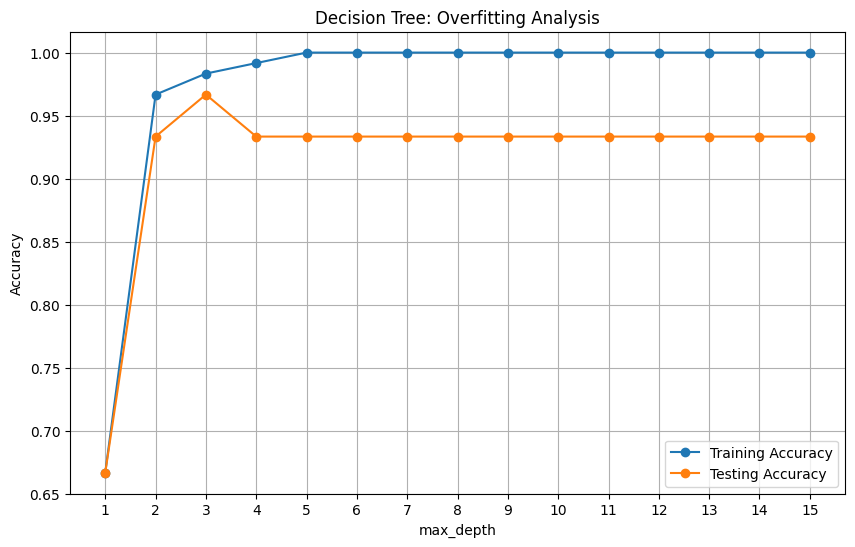

In [6]:
# ---------------------------------------------------

# 5. Plot

# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(

    depths,

    train_scores,

    marker='o',

    label='Training Accuracy'

)

plt.plot(

    depths,

    test_scores,

    marker='o',

    label='Testing Accuracy'

)

plt.xlabel("max_depth")

plt.ylabel("Accuracy")

plt.title("Decision Tree: Overfitting Analysis")

plt.xticks(list(depths))

plt.legend()

plt.grid(True)

plt.show()

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


def analyze_decision_tree(max_depth):

    # Create model with selected max_depth
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Print results
    print(f"max_depth = {max_depth}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy : {test_accuracy:.4f}")
    print(f"Accuracy Gap     : {train_accuracy - test_accuracy:.4f}")

    # Plot
    plt.figure(figsize=(10, 6))

    plt.plot(
        y_train,
        y_train_pred,
        'o',
        label="Training"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Decision Tree Analysis (max_depth={max_depth})")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

max_depth = 8
Training Accuracy: 1.0000
Testing Accuracy : 0.9333
Accuracy Gap     : 0.0667


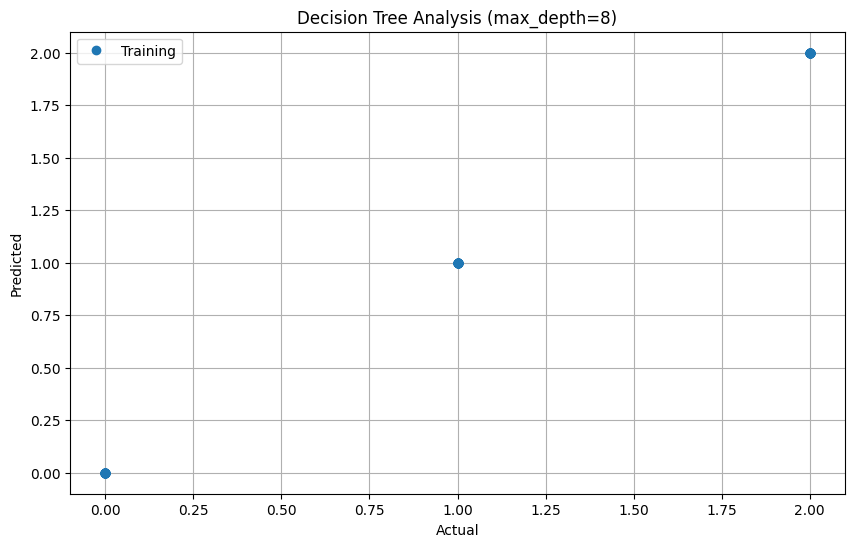

In [9]:
model = analyze_decision_tree(max_depth=8)